In [2]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#A sample graph with 4 nodes and unchanging edges
G = nx.DiGraph()

edges = [
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'C'),
    ('C', 'A'),
    ('D', 'C')
]

G.add_edges_from(edges)

print("Nodes:", G.nodes())
print("Edges:", G.edges())

Nodes: ['A', 'B', 'C', 'D']
Edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'A'), ('D', 'C')]


In [4]:
#Randomly generated graph
G = nx.gnp_random_graph(100, 0.05, directed=True)

In [6]:
nodes = list(G.nodes())
n = len(nodes)

adj_matrix = nx.to_numpy_array(G, nodelist=nodes)

print("Adjacency Matrix:\n", adj_matrix)

Adjacency Matrix:
 [[0. 1. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]


In [7]:
col_sum = adj_matrix.sum(axis=0)
M = np.divide(adj_matrix, col_sum, where=col_sum!=0)

for j in range(n):
    if col_sum[j] == 0:
        M[:, j] = 1 / n

print("Transition Matrix:\n", M)

Transition Matrix:
 [[0.         1.         0.33333333 0.25      ]
 [0.         0.         0.33333333 0.25      ]
 [1.         0.         0.         0.25      ]
 [0.         0.         0.33333333 0.25      ]]


In [8]:
def pagerank(M, d=0.85, max_iter=100, tol=1e-6):
    n = M.shape[0]
    r = np.ones(n) / n
    history = []

    for i in range(max_iter):
        r_new = d * M @ r + (1 - d) / n
        history.append(r_new.copy())

        if np.linalg.norm(r_new - r, 1) < tol:
            print(f"Converged in {i+1} iterations")
            break

        r = r_new

    return r, history

In [9]:
ranks, history = pagerank(M)

Converged in 20 iterations


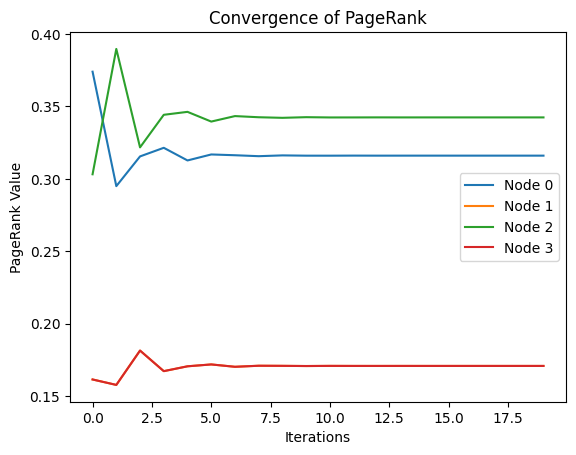

In [10]:
history = np.array(history)

for i in range(min(5, history.shape[1])):
    plt.plot(history[:, i], label=f'Node {i}')

plt.xlabel("Iterations")
plt.ylabel("PageRank Value")
plt.title("Convergence of PageRank")
plt.legend()
plt.show()

In [11]:
pagerank_df = pd.DataFrame({
    "Page": nodes,
    "Rank": ranks
}).sort_values(by="Rank", ascending=False)

print(pagerank_df)

  Page      Rank
2    C  0.342391
0    A  0.315994
1    B  0.170807
3    D  0.170807


In [12]:
nx_ranks = nx.pagerank(G, alpha=0.85)

nx_ranks_df = pd.DataFrame({
    "Page": list(nx_ranks.keys()),
    "NetworkX_Rank": list(nx_ranks.values())
}).sort_values(by="NetworkX_Rank", ascending=False)

comparison_df = pd.merge(pagerank_df, nx_ranks_df, on="Page", how="left")
print("\nPageRank Comparison:")
print(comparison_df)


PageRank Comparison:
  Page      Rank  NetworkX_Rank
0    C  0.342391       0.394150
1    A  0.315994       0.372526
2    B  0.170807       0.195824
3    D  0.170807       0.037500


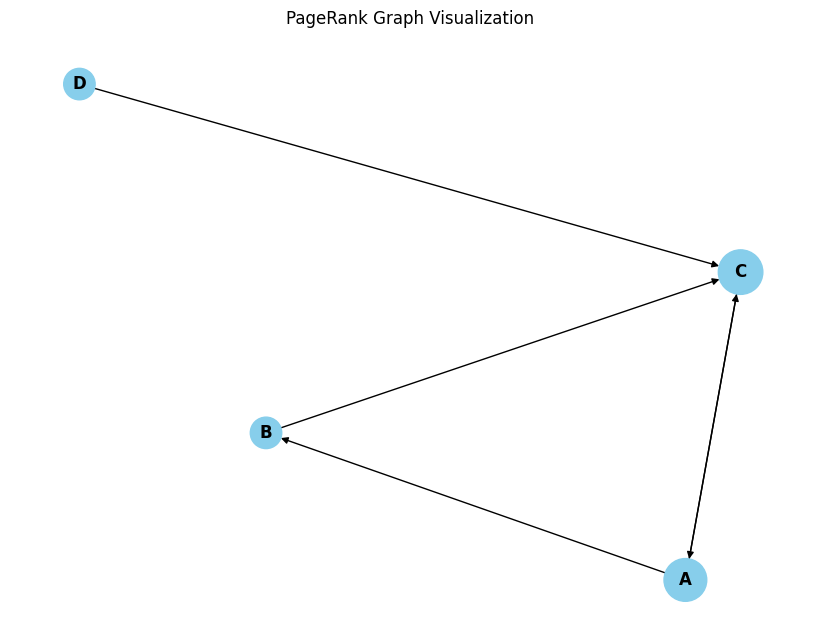

In [13]:
sizes = [r * 3000 for r in ranks]

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_size=sizes,
    node_color='skyblue',
    font_size=12,
    font_weight='bold',
    arrows=True
)

plt.title("PageRank Graph Visualization")
plt.show()

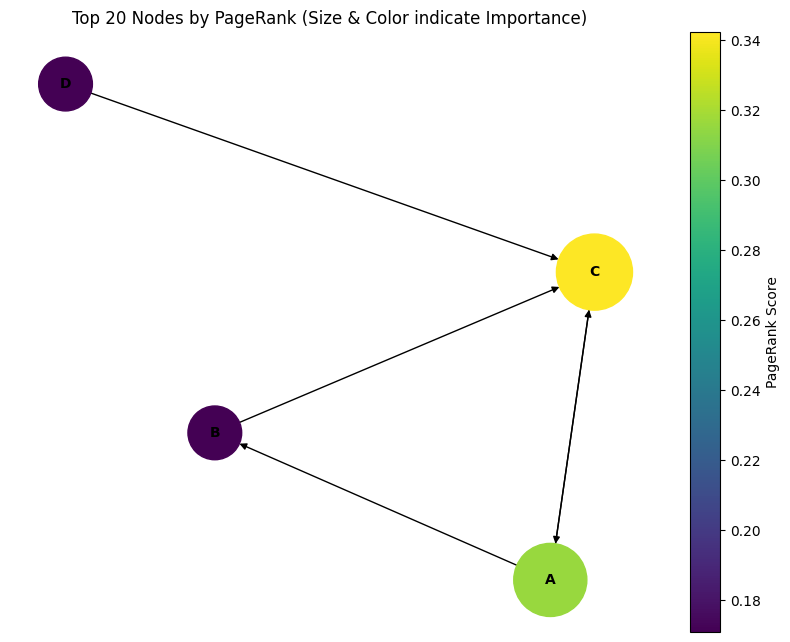

In [14]:

node_list = list(G.nodes())
rank_dict = {node_list[i]: ranks[i] for i in range(len(node_list))}

top_nodes = sorted(rank_dict, key=rank_dict.get, reverse=True)[:20]
subG = G.subgraph(top_nodes)

sub_ranks = np.array([rank_dict[n] for n in subG.nodes()])

node_sizes = 3000 * (sub_ranks / sub_ranks.max())
node_colors = sub_ranks

pos = nx.spring_layout(subG, seed=42)

plt.figure(figsize=(8,6))

nx.draw(
    subG, pos,
    with_labels=True,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    font_size=10,
    font_weight='bold',
    arrows=True
)

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=sub_ranks.min(), vmax=sub_ranks.max())
)
sm.set_array([])

plt.colorbar(sm, ax=plt.gca(), label="PageRank Score")

plt.title("Top 20 Nodes by PageRank (Size & Color indicate Importance)")
plt.show()